<a href="https://colab.research.google.com/github/Surajkr1166/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
df= pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.shape

(284807, 31)

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,...,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df['class'].value_counts()

,count
class,
0,284315
1,492


class
0    99.827251
1     0.172749
Name: class, dtype: float64


<Axes: ylabel='class'>

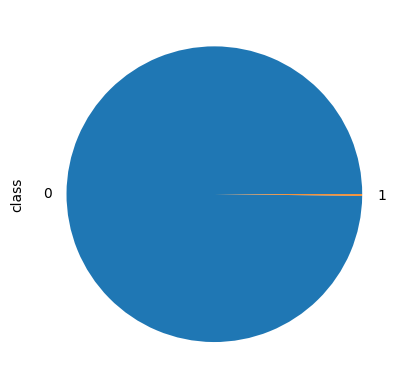

In [ ]:
#checking the class distibution of target variables in percentage
print((df.groupby('class')['class'].count()/df['class'].count())*100)
((df.groupby('class')['class'].count()/df['class'].count())*100).plot.pie()

In [ ]:
#checking the percentage distribution between normal and fraud
classes = df['class'].value_counts()
normal_share = classes[0] / df['class'].count()
fraud_share = classes[1] / df['class'].count()
print(f"Normal share: {normal_share * 100:.2f}%")
print(f"Fraud share: {fraud_share * 100:.2f}%")

Normal share: 99.83%
Fraud share: 0.17%


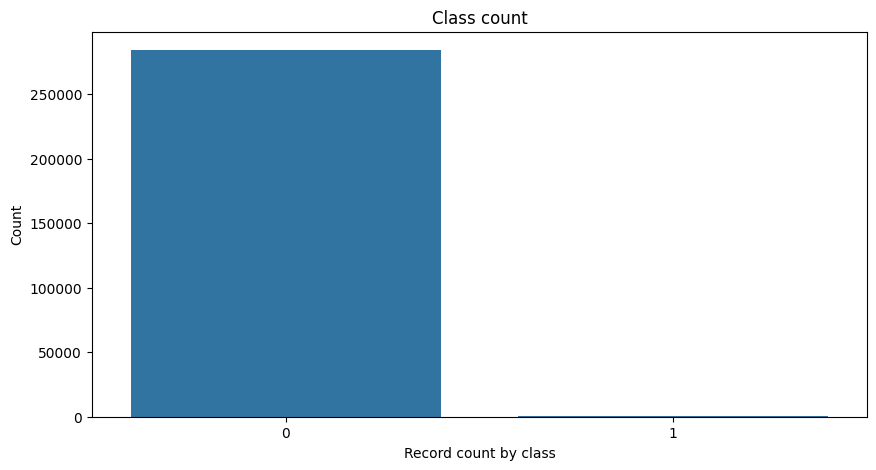

In [ ]:
#create a bar plot for number and percentage of fraudulent vs non fraudulent
plt.figure(figsize=(10,5))
sns.countplot(x='class',data=df)
plt.title('Class count')
plt.xlabel('Record count by class')
plt.ylabel('Count')
plt.show()

In [ ]:
#checking the correlation
corr = df.corr()
corr

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,3.777823e-12,-2.118614e-12,-1.733159e-13,-3.473231e-12,-1.306165e-13,-1.116494e-13,2.114527e-12,3.016285e-14,...,-3.276238e-12,2.281863e-12,-2.969746e-12,-1.029876e-12,1.144179e-12,1.835263e-12,7.624804e-12,-9.769215e-13,-0.227709,-0.101347
V2,-0.010593,3.777823e-12,1.000000e+00,2.325661e-12,-2.314981e-12,-1.831952e-12,9.438444e-13,5.403436e-12,2.133785e-14,3.238513e-13,...,2.280202e-12,-2.548560e-13,-4.856120e-12,6.431308e-13,-9.423730e-13,-4.129100e-13,-9.856545e-13,2.525513e-12,-0.531409,0.091289
V3,-0.419618,-2.118614e-12,2.325661e-12,1.000000e+00,2.046235e-13,-4.032993e-12,-1.574471e-13,3.405586e-12,-1.272385e-12,-6.812351e-13,...,6.736294e-13,-8.909339e-13,4.147209e-12,3.407636e-12,5.712956e-13,-2.577274e-12,-5.041444e-12,5.189109e-12,-0.210880,-0.192961
V4,-0.105260,-1.733159e-13,-2.314981e-12,2.046235e-13,1.000000e+00,-2.552389e-13,1.084041e-12,8.135064e-13,7.334818e-13,-7.143069e-13,...,-2.696370e-12,4.347776e-13,-4.160969e-12,-2.368743e-12,1.619944e-12,-3.043100e-13,-1.456066e-12,-2.832372e-12,0.098732,0.133447
V5,0.173072,-3.473231e-12,-1.831952e-12,-4.032993e-12,-2.552389e-13,1.000000e+00,-6.934789e-14,1.573956e-11,-2.038243e-12,-1.000756e-12,...,-1.751796e-12,7.095269e-13,3.616075e-12,-2.808776e-13,1.451126e-12,-1.896141e-13,-2.124559e-12,1.010196e-11,-0.386356,-0.094974
V6,-0.063016,-1.306165e-13,9.438444e-13,-1.574471e-13,1.084041e-12,-6.934789e-14,1.000000e+00,-2.798968e-12,-5.446480e-13,2.036743e-12,...,1.476858e-12,-1.144797e-12,-1.527842e-12,1.551854e-12,-2.723707e-12,3.351239e-12,1.481307e-12,-6.069227e-13,0.215981,-0.043643
V7,0.084714,-1.116494e-13,5.403436e-12,3.405586e-12,8.135064e-13,1.573956e-11,-2.798968e-12,1.000000e+00,5.528803e-12,5.088082e-13,...,2.788246e-12,-8.133209e-13,-4.293094e-12,-2.553518e-12,-7.406970e-13,-4.476467e-12,-1.328637e-11,2.958679e-13,0.397311,-0.187257
V8,-0.036949,2.114527e-12,2.133785e-14,-1.272385e-12,7.334818e-13,-2.038243e-12,-5.446480e-13,5.528803e-12,1.000000e+00,-2.243172e-12,...,-4.022440e-12,-2.679560e-12,9.013064e-13,-1.074365e-12,-3.268979e-12,1.043839e-12,-3.499804e-12,1.866598e-12,-0.103079,0.019875
V9,-0.008660,3.016285e-14,3.238513e-13,-6.812351e-13,-7.143069e-13,-1.000756e-12,2.036743e-12,5.088082e-13,-2.243172e-12,1.000000e+00,...,3.040326e-12,-7.467526e-13,-1.011003e-12,8.579072e-13,-1.590341e-12,-7.723547e-13,2.428930e-12,-1.406856e-12,-0.044246,-0.097733


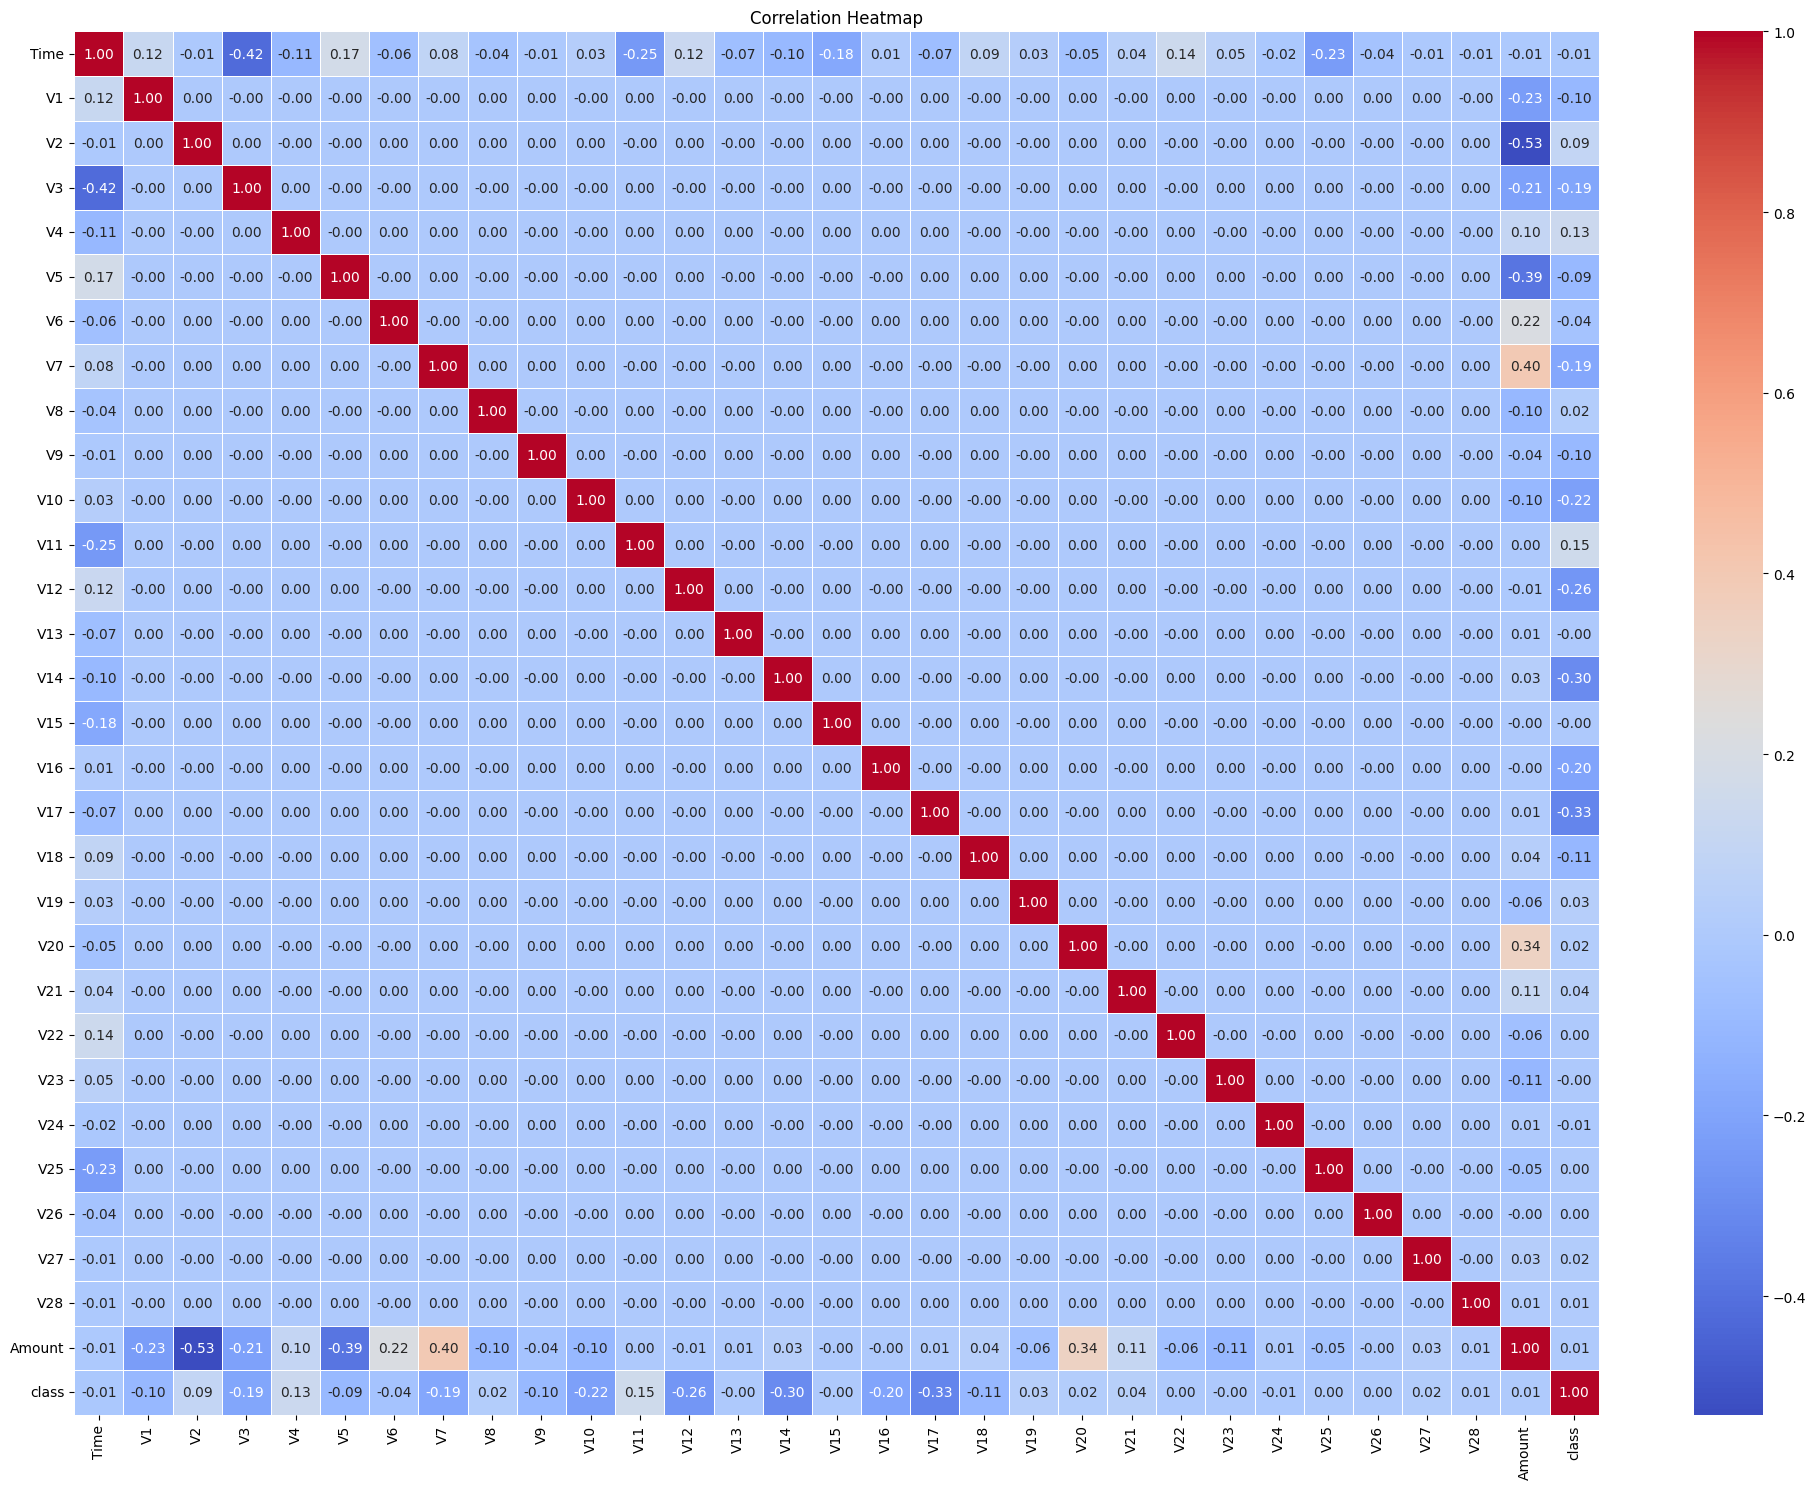

In [ ]:
# checking the correlation in heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
#as the time is given in  relative fashion, we are using pandas.timedelta which represent the duration the difference between two times
Delta_time = pd.to_timedelta(df['Time'],unit='s')

#create derived column mins and hours
df['Time_days'] = (Delta_time.dt.components.days).astype(int)
df['Time_hours'] = (Delta_time.dt.components.hours).astype(int)
df['Time_minutes'] = (Delta_time.dt.components.minutes).astype(int)


In [ ]:
#drop unneccesary column
#we will deop time as we have the derived day hour minute time
df.drop(['Time'],axis=1,inplace=True)
#we keep only derived column hour as day/time might not be very useful
df.drop(['Time_days' , 'Time_minutes'],axis=1,inplace=True)

**Splitting the data into train-test split**

In [ ]:
#splitting the data set into x and y
X = df.drop(['class'],axis=1)
y= df['class']

In [ ]:
#checking x
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time_hours
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#checking y
y.head()

,class
0,0
1,0
2,0
3,0
4,0


In [ ]:
#splitting the data using train test split
from sklearn.model_selection import train_test_split
X_train,y_train,X_test,y_test = train_test_split(X,y,test_size=0.2,random_state=100)

In [ ]:
#checking  the spread of data post split
print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

492
V1            7.286838e+00
V2            8.986756e+02
V3           -6.528676e+02
V4            4.379806e+02
V5            2.157077e+02
V6            1.392208e+01
V7            3.666098e+00
V8           -1.397782e+01
V9            3.629569e+02
V10           1.580144e+02
V11           1.391731e+02
V12           3.487528e+02
V13          -5.907352e+01
V14          -1.182467e+02
V15           7.929284e+01
V16          -5.769041e+01
V17           4.195622e+02
V18          -1.238187e+01
V19           1.119579e+02
V20          -7.187021e+01
V21           3.406802e+02
V22           1.174836e+02
V23           1.494223e+00
V24          -5.900090e+01
V25           1.092607e+02
V26           9.083036e+01
V27           2.294977e+01
V28           9.521106e+01
Amount        4.945149e+06
Time_hours    7.984520e+05
dtype: float64
96


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [ ]:
#accumulating all the column names under one variable
cols = list(X.columns.values)

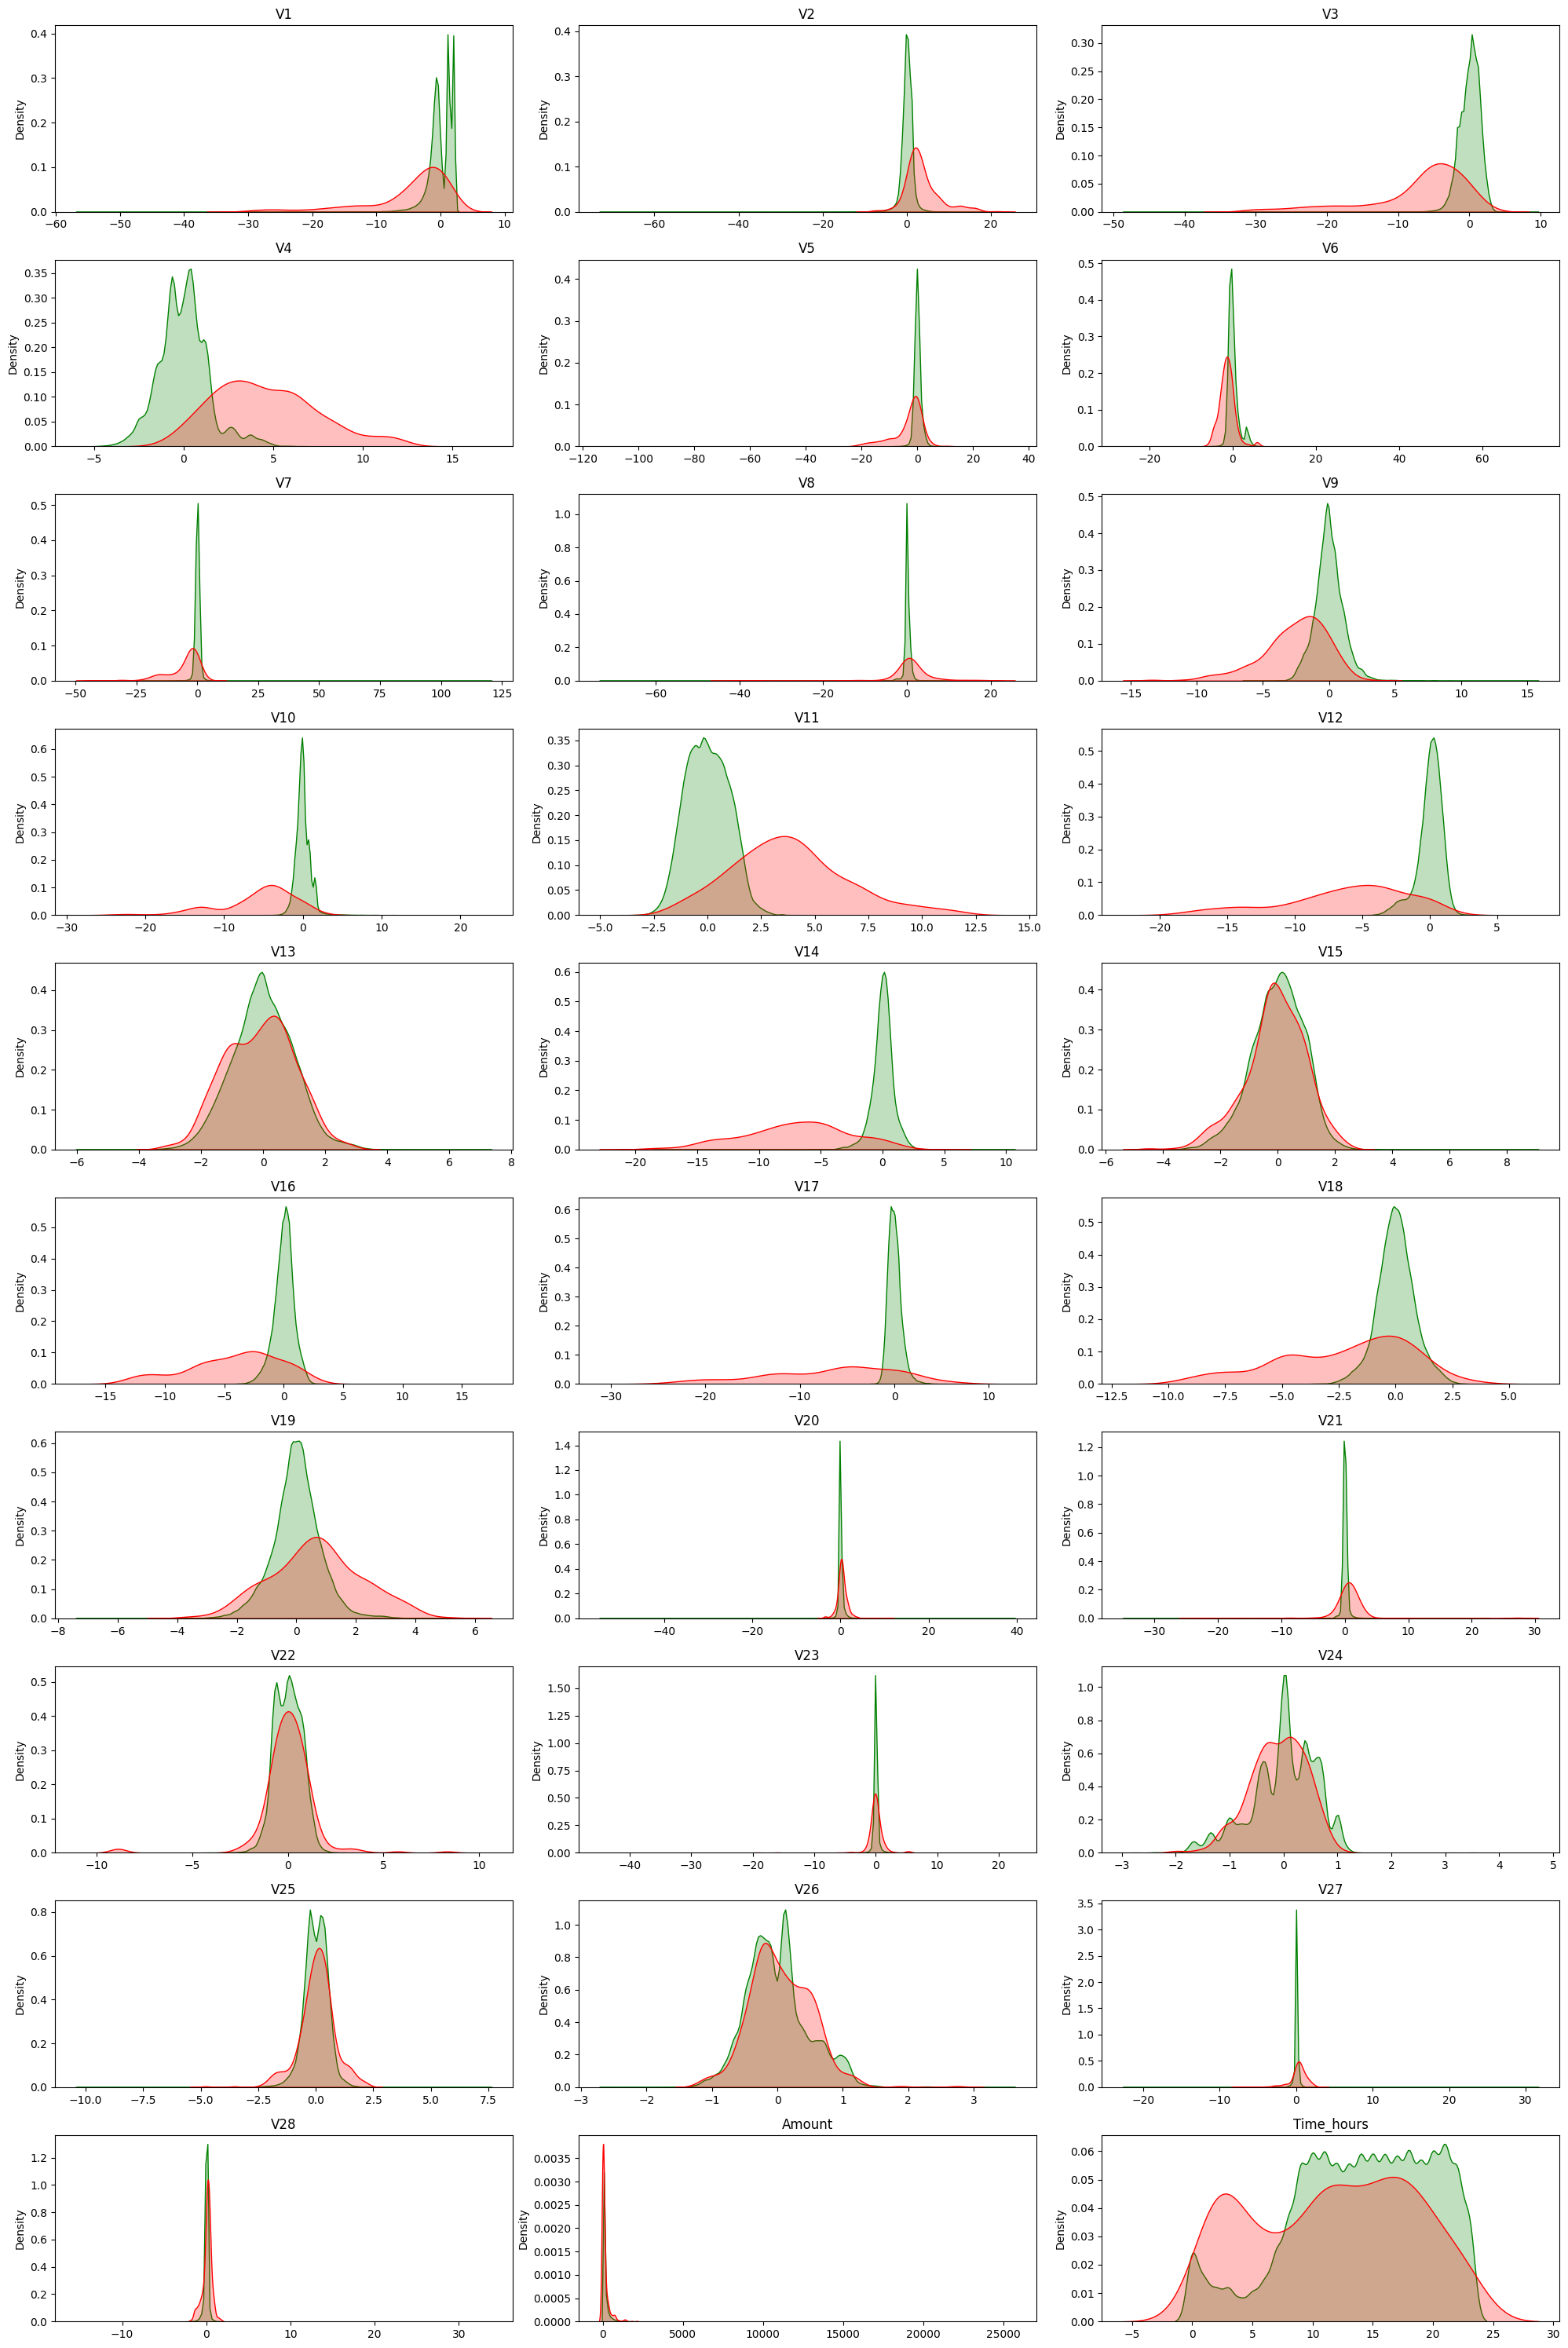

In [ ]:
normal_records = df['class'] == 0
fraud_records = df['class'] == 1

plt.figure(figsize=(20, 30))
for n, col in enumerate(cols):
    plt.subplot(10, 3, n + 1)
    sns.kdeplot(X.loc[normal_records, col], color='green', label='Normal', fill=True)
    sns.kdeplot(X.loc[fraud_records, col], color='red', label='Fraud', fill=True)
    plt.title(col)
    plt.xlabel('')

plt.tight_layout()
plt.show()

**Model building**

In [ ]:
#create a dataframe to store result
df_result = pd.DataFrame(columns=['Methodology', 'Model', 'Accuracy', 'roc_value', 'threshold'])

In [ ]:
# Created a common function to plot confusion matrix
def Plot_confusion_matrix(y_test, pred_test):
    cm = confusion_matrix(y_test, pred_test)
    plt.clf()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Accent)
    categoryNames = ['Non-Fraudulent', 'Fraudulent']
    plt.title('Confusion Matrix - Test Data')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    ticks = np.arange(len(categoryNames))
    plt.xticks(ticks, categoryNames, rotation=45)
    plt.yticks(ticks, categoryNames)
    s = [['TN', 'FP'], ['FN', 'TP']]

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(s[i][j]) + " = " + str(cm[i][j]), fontsize=12)
    plt.show()


In [ ]:
from sklearn import linear_model, metrics
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

def buildAndRunLogisticModels(df_Results, Methodology, X_train, y_train, X_test, y_test):
    num_C = list(np.power(10.0, np.arange(-10, 10)))
    cv_num = KFold(n_splits=10, shuffle=True, random_state=42)
    searchCV_l2 = linear_model.LogisticRegressionCV(Cs=num_C, penalty='l2', scoring='roc_auc', cv=cv_num, random_state=42, max_iter=10000, solver='newton-cg', tol=10)
    searchCV_l1 = linear_model.LogisticRegressionCV(Cs=num_C, penalty='l1', scoring='roc_auc', cv=cv_num, random_state=42, max_iter=10000, solver='liblinear', tol=10)
    searchCV_l1.fit(X_train, y_train)
    searchCV_l2.fit(X_train, y_train)
    y_pred_l1 = searchCV_l1.predict(X_test)
    y_pred_l2 = searchCV_l2.predict(X_test)
    y_pred_probs_l1 = searchCV_l1.predict_proba(X_test)[:, 1]
    y_pred_probs_l2 = searchCV_l2.predict_proba(X_test)[:, 1]

    # Using pd.concat instead of append
    res_l2 = pd.DataFrame({'Methodology': [Methodology], 'Model': ['Logistic Regression with L2 Regularisation']})
    df_Results = pd.concat([df_Results, res_l2], ignore_index=True)
    res_l1 = pd.DataFrame({'Methodology': [Methodology], 'Model': ['Logistic Regression with L1 Regularisation']})
    df_Results = pd.concat([df_Results, res_l1], ignore_index=True)
    return df_Results

In [ ]:
def buildAndRunKNNModels(df_Results, Methodology, X_train, y_train, X_test, y_test):
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=16)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    y_probs = knn.predict_proba(X_test)[:, 1]
    roc_val = metrics.roc_auc_score(y_test, y_probs)
    res = pd.DataFrame({'Methodology': [Methodology], 'Model': ['KNN'], 'Accuracy': [score], 'roc_value': [roc_val]})
    df_Results = pd.concat([df_Results, res], ignore_index=True)
    return df_Results

In [ ]:
def buildAndRunTreeModels(df_Results, Methodology, X_train, y_train, X_test, y_test):
    for c in ['gini', 'entropy']:
        dt = DecisionTreeClassifier(criterion=c, random_state=42)
        dt.fit(X_train, y_train)
        score = dt.score(X_test, y_test)
        res = pd.DataFrame({'Methodology': [Methodology], 'Model': [f'Tree Model {c}']})
        df_Results = pd.concat([df_Results, res], ignore_index=True)
    return df_Results

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

# ## Created a common function to fit and predict on a Random Forest model
def buildAndRunRandomForestModels(df_Results, Methodology, X_train, y_train, X_test, y_test):
    # Evaluate Random Forest model

    # Create the model with 100 trees
    RF_model = RandomForestClassifier(n_estimators=100,
                                     bootstrap=True,
                                     max_features='sqrt',
                                     random_state=42)

    # Fit on training data
    RF_model.fit(X_train, y_train)
    RF_test_score = RF_model.score(X_test, y_test)
    RF_model.predict(X_test)

    print('Model Accuracy: {0}'.format(RF_test_score))

    # Actual class predictions
    rf_predictions = RF_model.predict(X_test)

    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, rf_predictions)

    print("classification Report")
    print(metrics.classification_report(y_test, rf_predictions))

    # Probabilities for each class
    rf_probs = RF_model.predict_proba(X_test)[:, 1]

    # Calculate roc auc
    roc_value = metrics.roc_auc_score(y_test, rf_probs)
    print("Random Forest roc_value: {0}".format(roc_value))

    fpr, tpr, thresholds = metrics.roc_curve(y_test, rf_probs)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("Random Forest threshold: {0}".format(threshold))

    roc_auc = metrics.auc(fpr, tpr)
    print("ROC for the test dataset", '{:.1%}'.format(roc_auc))

    plt.plot(fpr, tpr, label="Test, auc="+str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    # Appending results to DataFrame using pd.concat
    new_row = pd.DataFrame({
        'Methodology': [Methodology],
        'Model': ['Random Forest'],
        'Accuracy': [RF_test_score],
        'roc_value': [roc_value]
    })
    df_Results = pd.concat([df_Results, new_row], ignore_index=True)

    return df_Results

In [ ]:
from xgboost import XGBClassifier
from sklearn import metrics

# ## Created a common function to fit and predict on a XGBoost model
def buildAndRunXGBoostModels(df_Results, Methodology, X_train, y_train, X_test, y_test):
    # Evaluate XGBoost model
    XGBmodel = XGBClassifier(random_state=42)
    XGBmodel.fit(X_train, y_train)
    y_pred = XGBmodel.predict(X_test)

    XGB_test_score = XGBmodel.score(X_test, y_test)
    print('Model Accuracy: {0}'.format(XGB_test_score))

    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, y_pred)

    print("classification Report")
    print(metrics.classification_report(y_test, y_pred))

    # Probabilities for each class
    XGB_probs = XGBmodel.predict_proba(X_test)[:, 1]

    # Calculate roc auc
    XGB_roc_value = metrics.roc_auc_score(y_test, XGB_probs)
    print("XGBoost roc_value: {0}".format(XGB_roc_value))

    fpr, tpr, thresholds = metrics.roc_curve(y_test, XGB_probs)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("XGBoost threshold: {0}".format(threshold))

    roc_auc = metrics.auc(fpr, tpr)
    print("ROC for the test dataset", '{:.1%}'.format(roc_auc))

    plt.plot(fpr, tpr, label="Test, auc="+str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    # Appending results to DataFrame
    df_Results = df_Results.append(pd.DataFrame({
        'Methodology': Methodology,
        'Model': 'XGBoost',
        'Accuracy': XGB_test_score,
        'roc_value': XGB_roc_value
    }, index=[0]), ignore_index=True)

    return df_Results

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score

# ## Created a common function to fit and predict on a SVM model
def buildAndRunSVMModels(df_Results, Methodology, X_train, y_train, X_test, y_test):
    # Evaluate SVM model with sigmoid kernel model

    clf = SVC(kernel='sigmoid', random_state=42)
    clf.fit(X_train, y_train)
    y_pred_SVM = clf.predict(X_test)

    SVM_Score = accuracy_score(y_test, y_pred_SVM)
    print("accuracy_score : {0}".format(SVM_Score))

    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, y_pred_SVM)

    print("classification Report")
    print(classification_report(y_test, y_pred_SVM))

    # Run classifier with probability=True for ROC calculation
    classifier = SVC(kernel='sigmoid', probability=True, random_state=42)
    svm_probs = classifier.fit(X_train, y_train).predict_proba(X_test)[:, 1]

    # Calculate roc auc
    roc_value = roc_auc_score(y_test, svm_probs)
    print("SVM roc_value: {0}".format(roc_value))

    fpr, tpr, thresholds = metrics.roc_curve(y_test, svm_probs)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("SVM threshold: {0}".format(threshold))

    roc_auc = metrics.auc(fpr, tpr)
    print("ROC for the test dataset", '{:.1%}'.format(roc_auc))

    plt.plot(fpr, tpr, label="Test, auc="+str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    # Appending results to DataFrame
    df_Results = df_Results.append(pd.DataFrame({
        'Methodology': Methodology,
        'Model': 'SVM',
        'Accuracy': SVM_Score,
        'roc_value': roc_value
    }, index=[0]), ignore_index=True)

    return df_Results

**Perform cross-validation with repeated k fold**

In [ ]:
# Lets perform RepeatedKFold and check the results
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=None)

# X is the feature set and y is the target
for train_index, test_index in rkf.split(X, y):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

TRAIN: [     0      1      3 ... 284803 284804 284806] TEST: [     2      9     20 ... 284791 284792 284805]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [     3     15     18 ... 284797 284802 284803]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [     7     10     17 ... 284795 284799 284801]
TRAIN: [     2      3      4 ... 284803 284805 284806] TEST: [     0      1     19 ... 284798 284800 284804]
TRAIN: [     0      1      2 ... 284803 284804 284805] TEST: [     4      5      6 ... 284778 284794 284806]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [     8     13     23 ... 284777 284779 284782]
TRAIN: [     2      3      4 ... 284803 284805 284806] TEST: [     0      1      6 ... 284794 284796 284804]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [     3     12     14 ... 284791 284793 284798]
TRAIN: [     0      1      3 ... 284804 284805 284806] TEST: [     2      7     10 ... 284797 284800 284801]
TRAIN: [     0     

Logistic Regression with L1 And L2 Regularisation
Time Taken by Model: --- 131.5230631828308 seconds ---
------------------------------------------------------------
KNN Model
Time Taken by Model: --- 189.66806364059448 seconds ---
------------------------------------------------------------
Decision Tree Models with 'gini' & 'entropy' criteria
Time Taken by Model: --- 52.32235097885132 seconds ---
------------------------------------------------------------
Random Forest Model
Model Accuracy: 0.999350432752234
Confusion Matrix


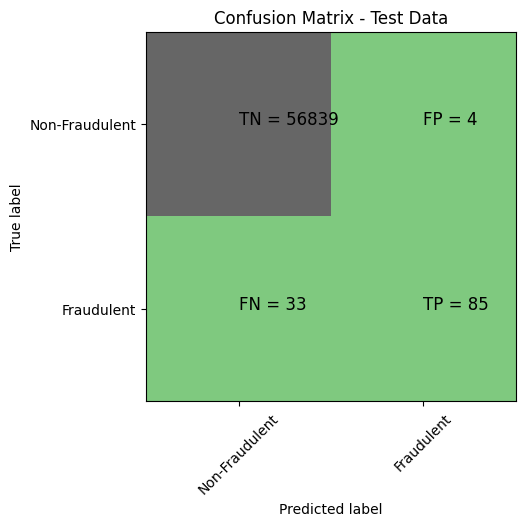

classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56843
           1       0.96      0.72      0.82       118

    accuracy                           1.00     56961
   macro avg       0.98      0.86      0.91     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest roc_value: 0.9261546149862079
Random Forest threshold: 0.01
ROC for the test dataset 92.6%


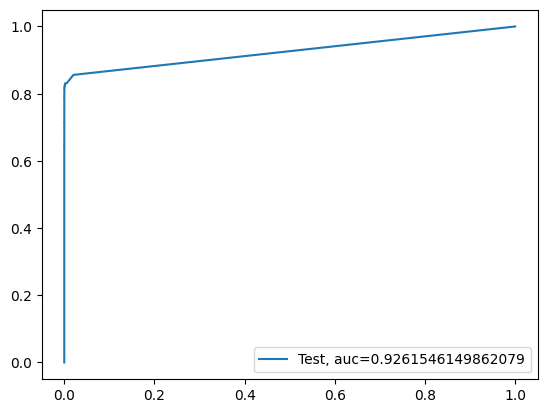

Time Taken by Model: --- 420.4892473220825 seconds ---
------------------------------------------------------------
XGBoost Model
Model Accuracy: 0.999280209265989
Confusion Matrix


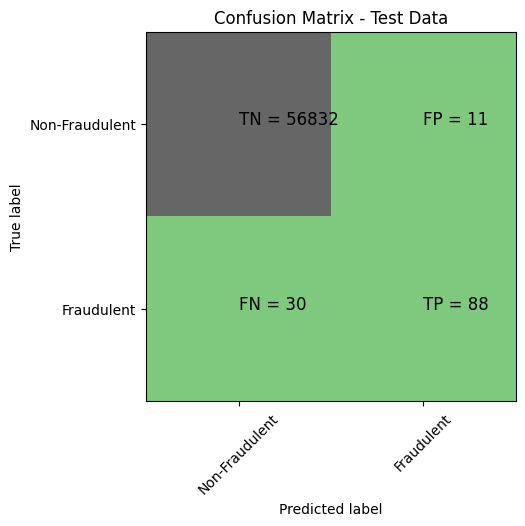

classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56843
           1       0.89      0.75      0.81       118

    accuracy                           1.00     56961
   macro avg       0.94      0.87      0.91     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost roc_value: 0.9064784298828441
XGBoost threshold: 8.440891542704776e-05
ROC for the test dataset 90.6%


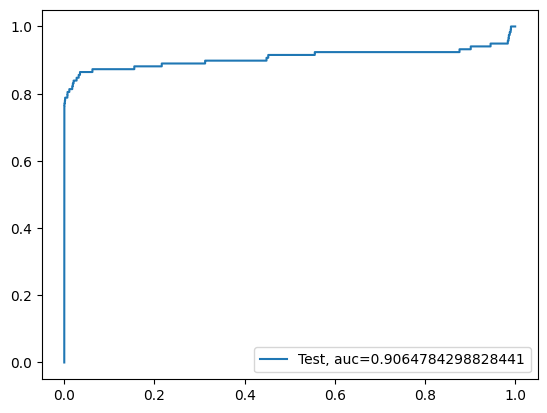

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
import time
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


# Pehle results dataframe aur methodology initialize kar lein
df_Results = pd.DataFrame()
Methodology = "RepeatedKFold CV"

# 1. Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 2. Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 3. Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 4. Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 5. Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 6. Run SVM Model
print("SVM Model")
start_time = time.time()
df_Results = buildAndRunSVMModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Final results display
print("All Models Executed!")
print(df_Results)

In [ ]:
#checking the df_result dataframe
df_Results


**Perform cross-validation with Stratified sampling**

In [ ]:
from sklearn.model_selection import StratifiedKFold

# 1. Stratified K-Fold Setup
# n_splits=5 matlab 5 bar check karega, shuffle=True randomness ke liye
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Pehla Split (Fold) nikalne ke liye
# Stratified split features (X) aur target (y) dono ko dekhta hai taaki
# Fraud/Non-Fraud ka ratio barabar rahe.
train_index, test_index = next(skf.split(X, y))

X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

print("Data Split Successfully using Stratified K-Fold!")
print(f"Training set size: {len(X_train_cv)}")
print(f"Test set size: {len(X_test_cv)}")

In [ ]:
import time

# Pehle results dataframe aur methodology initialize kar lein
df_Results = pd.DataFrame()
Methodology = "Stratified K-Fold"

# 1. Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 2. Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 3. Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 4. Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 5. Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# 6. Run SVM Model
print("SVM Model")
start_time = time.time()
df_Results = buildAndRunSVMModels(df_Results, Methodology, X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Final results display
print("Stratified Model Evaluation Complete!")
display(df_Results)

In [ ]:
import numpy as np
from sklearn import linear_model, metrics
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

# --- Model Configuration and Training ---
# Define range for C (Inverse of regularization strength)
num_C = list(np.power(10.0, np.arange(-10, 10)))
cv_num = KFold(n_splits=10, shuffle=True, random_state=42)

# Initialize LogisticRegressionCV with L2 penalty
clf = linear_model.LogisticRegressionCV(
    Cs=num_C,
    penalty='l2',
    scoring='roc_auc',
    cv=cv_num,
    random_state=42,
    max_iter=10000,
    fit_intercept=True,
    solver='newton-cg',
    tol=10
)

# Fit the model
clf.fit(X_train_SKF_cv, y_train_SKF_cv)

# Print Cross-Validation Results
print('Max auc_roc for l2:', clf.scores_[1].mean(axis=0).max())

# --- Parameters and Coefficients ---
print("Parameters for l2 regularisations")
print(clf.coef_)
print(clf.intercept_)
print(clf.scores_)

# --- Predictions ---
# Find predicted values
y_pred_l2 = clf.predict(X_test)

# Find predicted probabilities (for the positive class)
y_pred_probs_l2 = clf.predict_proba(X_test)[:, 1]

# --- Model Evaluation ---
# Accuracy Score
Accuracy_l2 = metrics.accuracy_score(y_pred=y_pred_l2, y_true=y_test)
print("Accuarcy of Logistic model with l2 regularisation : {0}".format(Accuracy_l2))

# ROC AUC Score
l2_roc_value = roc_auc_score(y_test, y_pred_probs_l2)
print("l2 roc_value: {0}".format(l2_roc_value))

# --- Threshold Optimization ---
# Calculating ROC Curve to find the optimal threshold (Youden's J statistic)
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_probs_l2)
threshold = thresholds[np.argmax(tpr - fpr)]
print("l2 threshold: {0}".format(threshold))

In [ ]:
import pandas as pd
import numpy as np

# --- Checking for the coefficient values ---
# This displays the raw array of weights assigned to each feature
clf.coef_

# --- Creating a dataframe with the coefficient values ---
# 1. pd.DataFrame(X.columns): Gets the names of the input features
# 2. pd.DataFrame(np.transpose(clf.coef_)): Converts the coefficient array into a column
# 3. pd.concat(..., axis=1): Combines the names and values side-by-side
coefficients = pd.concat([pd.DataFrame(X.columns), pd.DataFrame(np.transpose(clf.coef_))], axis=1)

# Renaming columns for clarity
coefficients.columns = ['Feature', 'Importance Coefficient']

# Display the resulting dataframe
coefficients

In [ ]:
#plotting the coefficient values
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Checking for the coefficient values ---
# This displays the raw weights learned by the model
clf.coef_

# --- Creating a dataframe with the coefficient values ---
# Links the feature names with their respective importance scores
coefficients = pd.concat([pd.DataFrame(X.columns), pd.DataFrame(np.transpose(clf.coef_))], axis=1)
coefficients.columns = ['Feature', 'Importance Coefficient']

# --- Plotting the coefficient values ---
# Set the visual dimensions for the plot
plt.figure(figsize=(20, 5))

# Create the bar plot using Seaborn
sns.barplot(x='Feature', y='Importance Coefficient', data=coefficients)

# Add title and display the plot
plt.title("Logistic Regression with L2 Regularisation Feature Importance", fontsize=18)
plt.show()

In [ ]:
# Creating the dataset with RandomOverSampler and StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import RandomOverSampler

skf = StratifiedKFold(n_splits=5, random_state=None)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train = X.loc[train_index]
    y_train = y.loc[train_index]
    X_test = X.loc[test_index]
    y_test = y.loc[test_index]

    ROS = RandomOverSampler(sampling_strategy=0.5)
    X_over, y_over = ROS.fit_resample(X_train, y_train)
X_over = pd.DataFrame(X_over, columns=X_train.columns)

In [ ]:
Data_Imbalance_Handiling = "Random Oversampling with StratifiedKFold CV "

# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

In [ ]:
df_Results


In [ ]:
# Creating dataframe with Smote and StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from imblearn import over_sampling

skf = StratifiedKFold(n_splits=5, random_state=None)

for fold, (train_index, test_index) in enumerate(skf.split(X,y), 1):
    X_train = X.loc[train_index]
    y_train = y.loc[train_index]
    X_test = X.loc[test_index]
    y_test = y.loc[test_index]
    SMOTE = over_sampling.SMOTE(random_state=0)
    X_train_Smote, y_train_Smote = SMOTE.fit_resample(X_train, y_train)

X_train_Smote = pd.DataFrame(data=X_train_Smote, columns=cols)

In [ ]:
Data_Imbalance_Handiling = "Random Oversampling with StratifiedKFold CV "

# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

In [ ]:
# Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

# Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

In [ ]:
df_Results

In [ ]:
# Creating dataframe with ADASYN and StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from imblearn import over_sampling

skf = StratifiedKFold(n_splits=5, random_state=None)

for fold, (train_index, test_index) in enumerate(skf.split(X,y), 1):
    X_train = X.loc[train_index]
    y_train = y.loc[train_index]
    X_test = X.loc[test_index]
    y_test = y.loc[test_index]

    ADASYN = over_sampling.ADASYN(random_state=0)
    X_train_ADASYN, y_train_ADASYN = ADASYN.fit_resample(X_train, y_train)

X_train_ADASYN = pd.DataFrame(data=X_train_ADASYN, columns=cols)

In [ ]:
Data_Imbalance_Handiling = "ADASYN Oversampling with StratifiedKFold CV "

# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*80)

# Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*80)

# Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*80)

# Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*80)

# Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*80)

In [ ]:
# Performing Hyperparameter tuning
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_test = {
    'max_depth': range(3, 10, 2),
    'min_child_weight': range(1, 6, 2),
    'n_estimators': range(60, 130, 150),
    'learning_rate': [0.05, 0.1, 0.125, 0.15, 0.2],
    'gamma': [i/10.0 for i in range(0, 5)],
    'subsample': [i/10.0 for i in range(7, 10)],
    'colsample_bytree': [i/10.0 for i in range(7, 10)]
}

gsearch1 = RandomizedSearchCV(estimator = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
                        colsample_bynode=1, max_delta_step=0,
                        missing=None, n_jobs=-1,
                        nthread=None, objective='binary:logistic', random_state=42,
                        reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
                        silent=None, verbosity=1),
                        param_distributions = param_test, n_iter=5, scoring='roc_auc', n_jobs=-1, cv=5)

gsearch1.fit(X_over, y_over)
gsearch1.cv_results_, gsearch1.best_params_, gsearch1.best_score_

In [ ]:
# Creating XGBoost model with selected hyperparameters
from xgboost import XGBClassifier

clf = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
                    colsample_bynode=1, colsample_bytree=0.7, gamma=0.2,
                    learning_rate=0.125, max_delta_step=0, max_depth=7,
                    min_child_weight=5, missing=None, n_estimators=60, n_jobs=1,
                    nthread=None, objective='binary:logistic', random_state=42,
                    reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
                    silent=None, subsample=0.8, verbosity=1)

# Fit on the dataset
clf.fit(X_over, y_over)
XGB_test_score = clf.score(X_test, y_test)
print('Model Accuracy: {0}'.format(XGB_test_score))

# Probabilities for each class
XGB_probs = clf.predict_proba(X_test)[:, 1]

# Calculate roc auc
from sklearn.metrics import roc_auc_score, roc_curve
XGB_roc_value = roc_auc_score(y_test, XGB_probs)

print("XGBoost roc_value: {0}".format(XGB_roc_value))
fpr, tpr, thresholds = metrics.roc_curve(y_test, XGB_probs)
threshold = thresholds[np.argmax(tpr - fpr)]
print("XGBoost threshold: {0}".format(threshold))

In [ ]:
import numpy as np

# Assuming 'clf' is your trained classifier (e.g., RandomForest, DecisionTree)
imp_var = []
for i in clf.feature_importances_:
    imp_var.append(i)

# Printing the top 3 variables by importance
# .index() finds the position, np.sort() orders them, and +1 adjusts for 1-based indexing
print('Top var =', imp_var.index(np.sort(clf.feature_importances_)[-1]) + 1)
print('2nd Top var =', imp_var.index(np.sort(clf.feature_importances_)[-2]) + 1)
print('3rd Top var =', imp_var.index(np.sort(clf.feature_importances_)[-3]) + 1)

In [ ]:
import numpy as np
from sklearn import metrics

# Calculate roc auc
XGB_roc_value = metrics.roc_auc_score(y_test, XGB_probs)

print("XGboost roc_value: {0}".format(XGB_roc_value))

# Calculate ROC curve components
fpr, tpr, thresholds = metrics.roc_curve(y_test, XGB_probs)

# Identify the optimal threshold where (TPR - FPR) is maximized
threshold = thresholds[np.argmax(tpr - fpr)]

print("XGBoost threshold: {0}".format(threshold))